In [1]:
#import statements
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import nilearn.image
import nilearn.plotting
import copy
from torch.utils.data import random_split
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from pathlib import Path
import ants
import pydicom
import nibabel as nib
import os
from glob import glob
from tqdm import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary
import nilearn
import pyarrow.parquet as pq
from sklearn.model_selection import StratifiedGroupKFold


In [3]:
DATA     = Path("model_data/adni")
T1_LONG  = DATA / "t1_long_data"
DTI_LONG = DATA / "dti_long_data"

meta = pd.read_csv(DATA / "paired_df_long.csv")
MODALITIES = ["t1_gm", "t1_wm", "t1_csf", "dti_gm", "dti_wm", "dti_csf"]

print(f"Cohort: {len(meta)} paired subjects")
print("group:  ", meta["group"].value_counts().to_dict())
print("amyloid:", meta["amyloid_label"].value_counts(dropna=False).to_dict())

Cohort: 786 paired subjects
group:   {'CN': 420, 'MCI': 286, 'Dementia': 80}
amyloid: {1.0: 376, 0.0: 347, nan: 63}


In [4]:
key_col = {
    "t1_gm":  "t1_image_subject_id",
    "t1_wm":  "t1_image_subject_id",
    "t1_csf": "t1_image_subject_id",
    "dti_gm": "dti_image_subject_id",
    "dti_wm": "dti_image_subject_id",
    "dti_csf":"dti_image_subject_id",
}
parquet_paths = {
    "t1_gm":  T1_LONG  / "t1_long_masked_gm.parquet",
    "t1_wm":  T1_LONG  / "t1_long_masked_wm.parquet",
    "t1_csf": T1_LONG  / "t1_long_masked_csf.parquet",
    "dti_gm": DTI_LONG / "dti_long_masked_gm_md.parquet",
    "dti_wm": DTI_LONG / "dti_long_masked_wm_md.parquet",
    "dti_csf":DTI_LONG / "dti_long_masked_csf_md.parquet",
}

# Parquets can exceed pyarrow's default thrift limit (~1 GB metadata) — raise it.
def _read_parquet(path):
    return pq.read_pandas(str(path),
                          thrift_string_size_limit=2_000_000_000,
                          thrift_container_size_limit=2_000_000_000).to_pandas()

X_raw = {}
for k, p in parquet_paths.items():
    df = _read_parquet(p)
    X_raw[k] = df.loc[meta[key_col[k]]].values.astype(np.float32)
    print(f"  {k}: {X_raw[k].shape}")

  t1_gm: (786, 831863)
  t1_wm: (786, 785285)
  t1_csf: (786, 337620)
  dti_gm: (786, 831863)
  dti_wm: (786, 785285)
  dti_csf: (786, 337620)


In [5]:
# 4-class: CN×amy0, CN×amy1, Impaired×amy0, Impaired×amy1
amy_mask = (meta["group"].isin(["CN", "MCI", "Dementia"]) & meta["amyloid_label"].notna()).values

g4_raw = meta.loc[amy_mask, "group"].values
g4 = np.where(np.isin(g4_raw, ["MCI", "Dementia"]), "Impaired", g4_raw)
a4 = meta.loc[amy_mask, "amyloid_label"].values.astype(int)

label_map_4 = {("CN", 0): 0, ("CN", 1): 1, ("Impaired", 0): 2, ("Impaired", 1): 3}
y4      = np.array([label_map_4[(g, a)] for g, a in zip(g4, a4)], dtype=np.int64)
idx4    = np.where(amy_mask)[0]
groups4 = meta.loc[amy_mask, "subject_id"].values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
local_tr, local_te = next(sgkf.split(np.arange(len(y4)), y4, groups4))
y4_tr, y4_te = y4[local_tr], y4[local_te]

assert len(set(groups4[local_tr]) & set(groups4[local_te])) == 0, "Subject leakage!"

print(f"4-class split: total={len(y4)}  train={len(local_tr)}  test={len(local_te)}")
for cls, name in enumerate(["CN_amy0", "CN_amy1", "Impaired_amy0", "Impaired_amy1"]):
    print(f"  class {cls} ({name}): {(y4 == cls).sum()}")

4-class split: total=723  train=574  test=149
  class 0 (CN_amy0): 203
  class 1 (CN_amy1): 183
  class 2 (Impaired_amy0): 144
  class 3 (Impaired_amy1): 193


In [6]:
cn_mask = meta["group"].eq("CN").values
PC_RANGE = list(range(1, 51))
scalers = {}
scree_records, bacc_records = [], []

for mod in MODALITIES:
    X_mod = X_raw[mod].astype(np.float32)
    scaler = StandardScaler().fit(X_mod[cn_mask])
    scalers[mod] = scaler

    X_full = scaler.transform(X_mod)
    X4     = X_full[idx4]
    X4_tr  = X4[local_tr]
    X4_te  = X4[local_te]

    pca = PCA(n_components=50, random_state=0, svd_solver="randomized").fit(X4_tr)
    evr = pca.explained_variance_ratio_
    Z_tr = pca.transform(X4_tr)
    Z_te = pca.transform(X4_te)

    for n_pc in PC_RANGE:
        scree_records.append({"modality": mod, "n_pc": n_pc, "var_explained": float(evr[n_pc - 1])})
        clf  = SVC(class_weight="balanced", random_state=0,
                   decision_function_shape="ovr").fit(Z_tr[:, :n_pc], y4_tr)
        bacc = balanced_accuracy_score(y4_te, clf.predict(Z_te[:, :n_pc]))
        bacc_records.append({"modality": mod, "n_pc": n_pc, "bAcc": float(bacc)})

    print(f"  {mod} done")

scree_df = pd.DataFrame(scree_records)
bacc_df  = pd.DataFrame(bacc_records)

  t1_gm done
  t1_wm done
  t1_csf done
  dti_gm done
  dti_wm done
  dti_csf done


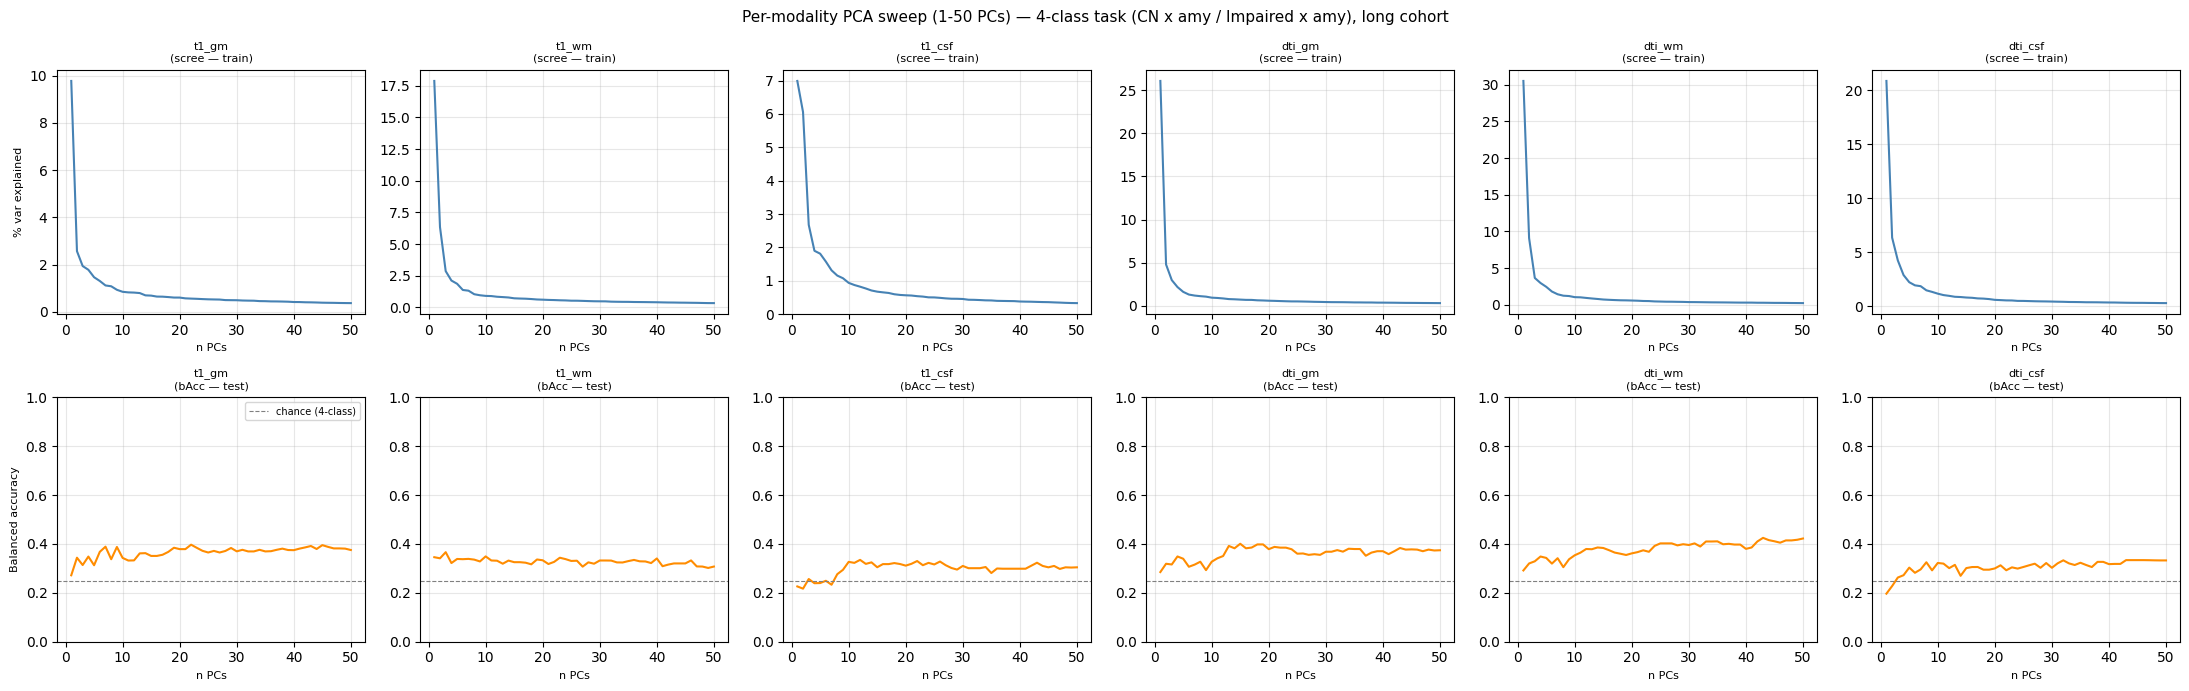

In [7]:
fig, axes = plt.subplots(2, 6, figsize=(22, 7))

for col, mod in enumerate(MODALITIES):
    sub_s = scree_df[scree_df["modality"] == mod]
    sub_b = bacc_df[bacc_df["modality"]  == mod]

    ax_s = axes[0, col]
    ax_s.plot(sub_s["n_pc"], sub_s["var_explained"] * 100, color="steelblue", lw=1.5)
    ax_s.set_title(f"{mod}\n(scree — train)", fontsize=8)
    ax_s.set_xlabel("n PCs", fontsize=8)
    ax_s.set_ylabel("% var explained" if col == 0 else "", fontsize=8)
    ax_s.grid(True, alpha=0.3)

    ax_b = axes[1, col]
    ax_b.plot(sub_b["n_pc"], sub_b["bAcc"], color="darkorange", lw=1.5)
    ax_b.axhline(0.25, color="grey", lw=0.8, ls="--", label="chance (4-class)")
    ax_b.set_xlabel("n PCs", fontsize=8)
    ax_b.set_ylabel("Balanced accuracy" if col == 0 else "", fontsize=8)
    ax_b.set_title(f"{mod}\n(bAcc — test)", fontsize=8)
    ax_b.set_ylim(0, 1)
    ax_b.grid(True, alpha=0.3)
    if col == 0:
        ax_b.legend(fontsize=7)

fig.suptitle(
    "Per-modality PCA sweep (1-50 PCs) — 4-class task (CN x amy / Impaired x amy), long cohort",
    fontsize=11,
)
plt.tight_layout()
plt.show()

In [9]:
# Group subsets for downstream analysis
impaired_mask = meta["group"].isin(["MCI", "Dementia"])

cn_amyloid_0       = meta[(meta["group"] == "CN")  & (meta["amyloid_label"] == 0)]
cn_amyloid_1       = meta[(meta["group"] == "CN")  & (meta["amyloid_label"] == 1)]
impaired_amyloid_0 = meta[impaired_mask             & (meta["amyloid_label"] == 0)]
impaired_amyloid_1 = meta[impaired_mask             & (meta["amyloid_label"] == 1)]

print(f"CN amy-: {len(cn_amyloid_0)}  CN amy+: {len(cn_amyloid_1)}")
print(f"Impaired amy-: {len(impaired_amyloid_0)}  Impaired amy+: {len(impaired_amyloid_1)}")

CN amy-: 203  CN amy+: 183
Impaired amy-: 144  Impaired amy+: 193


In [10]:
# CN-normalized X for the MCI+Dementia subset (useful for deviation-score analyses)
mci_dem_mask = meta["group"].isin(["MCI", "Dementia"]).values

X_scaled = {
    mod: scalers[mod].transform(X_raw[mod][mci_dem_mask].astype(np.float32))
    for mod in MODALITIES
}
print({mod: X_scaled[mod].shape for mod in MODALITIES})

{'t1_gm': (366, 831863), 't1_wm': (366, 785285), 't1_csf': (366, 337620), 'dti_gm': (366, 831863), 'dti_wm': (366, 785285), 'dti_csf': (366, 337620)}


In [11]:
# --- CN vs MCI+Dementia: balanced SVM, 15 PCs per modality -------------------
N_PC = 15

y_bin      = meta["diag_label"].values          # 0=CN, 1=MCI/Dementia
groups_bin = meta["subject_id"].values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
tr, te = next(sgkf.split(np.arange(len(y_bin)), y_bin, groups_bin))
y_tr, y_te = y_bin[tr], y_bin[te]

print(f"Train: CN={(y_tr==0).sum()}  Impaired={(y_tr==1).sum()}")
print(f"Test:  CN={(y_te==0).sum()}  Impaired={(y_te==1).sum()}")
print()
print(f"{'Modality':<12}  {'bAcc':>6}  {'Sens':>6}  {'Spec':>6}")
print("-" * 38)

from sklearn.metrics import confusion_matrix

for mod in MODALITIES:
    Xs       = scalers[mod].transform(X_raw[mod].astype(np.float32))
    pca      = PCA(n_components=N_PC, random_state=0, svd_solver="randomized").fit(Xs[tr])
    Z_tr     = pca.transform(Xs[tr])
    Z_te     = pca.transform(Xs[te])
    clf      = SVC(class_weight="balanced", random_state=0).fit(Z_tr, y_tr)
    y_pred   = clf.predict(Z_te)
    bacc     = balanced_accuracy_score(y_te, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else float("nan")
    spec = tn / (tn + fp) if (tn + fp) else float("nan")
    print(f"{mod:<12}  {bacc:>6.3f}  {sens:>6.3f}  {spec:>6.3f}")

Train: CN=341  Impaired=305
Test:  CN=79  Impaired=61

Modality        bAcc    Sens    Spec
--------------------------------------
t1_gm          0.676   0.541   0.810
t1_wm          0.701   0.541   0.861
t1_csf         0.688   0.705   0.671
dti_gm         0.663   0.541   0.785
dti_wm         0.669   0.541   0.797
dti_csf        0.684   0.672   0.696


In [12]:
# --- Amyloid +/- prediction: balanced SVM, 15 PCs per modality ---------------
amy_valid  = meta["amyloid_label"].notna().values
y_amy      = meta.loc[amy_valid, "amyloid_label"].astype(int).values
groups_amy = meta.loc[amy_valid, "subject_id"].values
idx_amy    = np.where(amy_valid)[0]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
tr, te = next(sgkf.split(np.arange(len(y_amy)), y_amy, groups_amy))
y_tr, y_te = y_amy[tr], y_amy[te]

print(f"Train: amy-={(y_tr==0).sum()}  amy+={(y_tr==1).sum()}")
print(f"Test:  amy-={(y_te==0).sum()}  amy+={(y_te==1).sum()}")
print()
print(f"{'Modality':<12}  {'bAcc':>6}  {'Sens+':>6}  {'Spec-':>6}")
print("-" * 38)

for mod in MODALITIES:
    Xs   = scalers[mod].transform(X_raw[mod].astype(np.float32))
    Xsub = Xs[idx_amy]
    pca  = PCA(n_components=N_PC, random_state=0, svd_solver="randomized").fit(Xsub[tr])
    Z_tr = pca.transform(Xsub[tr])
    Z_te = pca.transform(Xsub[te])
    clf  = SVC(class_weight="balanced", random_state=0).fit(Z_tr, y_tr)
    y_pred = clf.predict(Z_te)
    bacc = balanced_accuracy_score(y_te, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else float("nan")
    spec = tn / (tn + fp) if (tn + fp) else float("nan")
    print(f"{mod:<12}  {bacc:>6.3f}  {sens:>6.3f}  {spec:>6.3f}")

Train: amy-=273  amy+=314
Test:  amy-=74  amy+=62

Modality        bAcc   Sens+   Spec-
--------------------------------------
t1_gm          0.588   0.581   0.595
t1_wm          0.507   0.339   0.676
t1_csf         0.547   0.500   0.595
dti_gm         0.512   0.403   0.622
dti_wm         0.538   0.387   0.689
dti_csf        0.580   0.565   0.595
